# Load inflation data

In [374]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import pickle
inflation_df = pd.read_csv(r"c:\Users\Madhurima Acharya\OneDrive\Desktop\IT Career switch 2\fuel-inflation-analysis\data\cpi inflation data.csv", encoding="latin1", skiprows = 2)
print(inflation_df.head())


   L55O    Unnamed: 1 Unnamed: 2  Unnamed: 3  Unnamed: 4 Unnamed: 5  \
0     NaN        2006        2.5         2.2         2.2          2   
1     NaN        2007        2.4         2.7         2.7        2.9   
2     NaN        2008        3.5         2.4         2.6        2.6   
3     NaN        2009          2         2.9         3.1        2.8   
4     NaN        2010        2.5         2.6         2.1        2.4   

  Unnamed: 6 Unnamed: 7 Unnamed: 8 Unnamed: 9 Unnamed: 10 Unnamed: 11  \
0        2.2        2.4        2.6        2.5         2.6         2.5   
1        2.7        2.5        2.5          2           2           2   
2          3        3.3        3.7        4.2         4.4         4.8   
3        2.3        2.1        1.7        1.6         1.4           1   
4        2.7        2.5        2.4        2.3         2.4         2.4   

  Unnamed: 12 Unnamed: 13 Unnamed: 14  
0         2.5         2.8         2.9  
1         2.3         2.2         2.3  
2         4.2 

# Data cleaning 
Handle missing values
Fix columns
Convert dates

In [375]:
inflation_df.columns = [
    "Code", "Year", "Annual", "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# inflation_df.head()

In [376]:
inflation_df = inflation_df.drop(columns=["Code", "Annual"])
inflation_df.head()


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,2006,2.2,2.2,2,2.2,2.4,2.6,2.5,2.6,2.5,2.5,2.8,2.9
1,2007,2.7,2.7,2.9,2.7,2.5,2.5,2,2,2,2.3,2.2,2.3
2,2008,2.4,2.6,2.6,3,3.3,3.7,4.2,4.4,4.8,4.2,3.8,3
3,2009,2.9,3.1,2.8,2.3,2.1,1.7,1.6,1.4,1,1.2,1.5,2.1
4,2010,2.6,2.1,2.4,2.7,2.5,2.4,2.3,2.4,2.4,2.5,2.6,3.1


# Data Transformation
 Melt inflation data
 Convert weekly → monthly (fuel)

In [377]:
inflation_long = inflation_df.melt(
    id_vars="Year",
    var_name="Month",
    value_name="Inflation_Rate"
)

# inflation_long.head()

In [378]:
inflation_long["Date"] = inflation_long["Year"].astype(str) + "-" + inflation_long["Month"]
# inflation_long.head()


In [379]:
inflation_long = inflation_long.sort_values(by=["Year", "Month"])
# inflation_long.head(10)


In [380]:
inflation_long = inflation_long.reset_index(drop=True)


In [381]:
month_map = {
    "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04",
    "May": "05", "Jun": "06", "Jul": "07", "Aug": "08",
    "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12"
}

inflation_long["Month_Num"] = inflation_long["Month"].map(month_map)

inflation_long["Date"] = inflation_long["Year"].astype(str) + "-" + inflation_long["Month_Num"]
inflation_long = inflation_long.sort_values(by=["Year", "Month_Num"])
inflation_long = inflation_long.reset_index(drop=True)

# inflation_long.head(12)


In [382]:
inflation_final = inflation_long[["Date", "Inflation_Rate"]]
inflation_final = inflation_final[inflation_final["Date"] >= "2018-01"]
# inflation_final.head(10)


# Fuel data load

In [383]:
fuel_df = pd.read_csv("../data/weekly-road-fuel-prices-2018-2026.csv")
# fuel_df.head()

# Data cleaning

In [384]:
fuel_df = fuel_df.rename(columns={
    "ULSP (Ultra low sulphur unleaded petrol) Pump price in pence/litre": "Petrol_Price",
    "ULSD (Ultra low sulphur diesel) Pump price in pence/litre": "Diesel_Price"
})

fuel_df.columns

Index(['Date', 'Petrol_Price', 'Diesel_Price',
       'ULSP (Ultra low sulphur unleaded petrol) Duty rate in pence/litre',
       'ULSD (Ultra low sulphur diesel) Duty rate in pence/litre',
       'ULSP (Ultra low sulphur unleaded petrol) VAT percentage rate',
       'ULSD (Ultra low sulphur diesel) VAT percentage rate'],
      dtype='object')

In [385]:
fuel_df = fuel_df[["Date", "Petrol_Price", "Diesel_Price"]]
fuel_df["Date"] = pd.to_datetime(fuel_df["Date"], dayfirst=True)
fuel_df["Date"] = fuel_df["Date"].dt.to_period("M").astype(str)

In [386]:
fuel_monthly = fuel_df.groupby("Date").mean().reset_index()
# fuel_monthly.head(10)

# Data merging

In [387]:
final_df = pd.merge(inflation_final, fuel_monthly, on="Date", how="inner")

final_df = final_df.replace("..", np.nan)
final_df = final_df.dropna()
# final_df.head()

In [388]:
final_df.shape
final_df.columns

Index(['Date', 'Inflation_Rate', 'Petrol_Price', 'Diesel_Price'], dtype='object')

In [389]:
final_df["Inflation_Rate"] = pd.to_numeric(final_df["Inflation_Rate"])
final_df["Petrol_Price"] = pd.to_numeric(final_df["Petrol_Price"])
final_df["Diesel_Price"] = pd.to_numeric(final_df["Diesel_Price"])
final_df = final_df.dropna()
# print(final_df.head())

# Plot trends

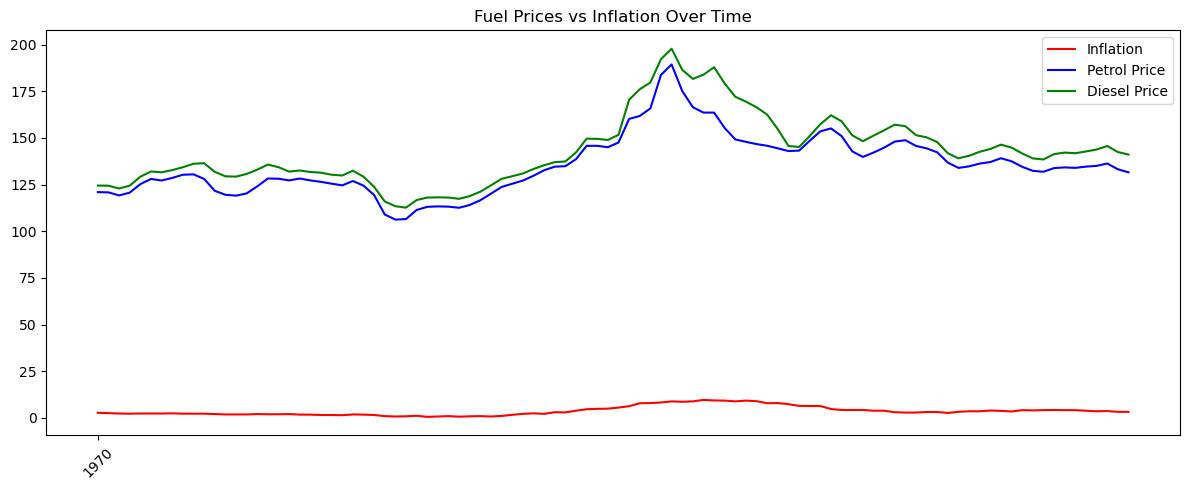

In [390]:

import matplotlib.dates as mdates

plt.figure(figsize=(12,5))

plt.plot(final_df["Date"], final_df["Inflation_Rate"], label="Inflation", color="red")
plt.plot(final_df["Date"], final_df["Petrol_Price"], label="Petrol Price", color="blue")
plt.plot(final_df["Date"], final_df["Diesel_Price"], label="Diesel Price", color="green")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())  # show yearly ticks
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)
plt.legend()
plt.title("Fuel Prices vs Inflation Over Time")

plt.tight_layout()
plt.show()

# Data coorelation analysis

In [391]:
final_df.corr(numeric_only=True)

,Inflation_Rate,Petrol_Price,Diesel_Price
Inflation_Rate,1.000000,0.866197,0.913953
Petrol_Price,0.866197,1.000000,0.974760
Diesel_Price,0.913953,0.974760,1.000000


# Visualize correlation

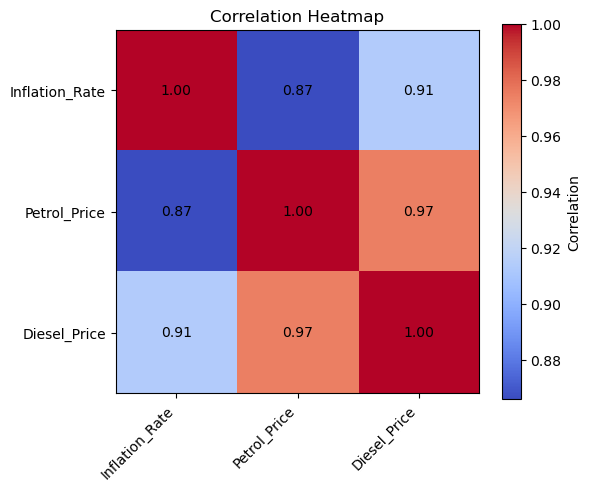

In [392]:

corr = final_df.corr(numeric_only=True)
plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm", aspect="equal")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iat[i, j]:.2f}", ha="center", va="center", color="black")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Key Insights

- There is a positive correlation between fuel prices and inflation.
- Diesel prices show slightly stronger correlation with inflation compared to petrol.
- A significant spike in fuel prices is observed around 2022, which aligns with increased inflation.
- This suggests that rising fuel costs may contribute to overall inflation trends.

##Note
Initially, the analysis focused on understanding the relationship between fuel prices and inflation. A moderate positive relationship was observed, suggesting that increases in fuel prices may contribute to rising inflation.
However, inflation is influenced by multiple macroeconomic factors rather than a single variable. To develop a more robust and realistic analysis, additional features such as interest rates and unemployment were incorporated alongside fuel prices. This expanded approach allows for a better understanding of the relative impact of different economic indicators on inflation.



# Load & clean interest rate data


In [393]:
interest_df = pd.read_csv("../data/interest rate.csv")

interest_df.columns = ["Date", "Interest Rate"]

interest_df["Date"] = pd.to_datetime(interest_df["Date"], dayfirst=True)

interest_df = interest_df.sort_values("Date")


C:\Users\Madhurima Acharya\AppData\Local\Temp\ipykernel_23376\3903395244.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  interest_df["Date"] = pd.to_datetime(interest_df["Date"], dayfirst=True)


# Convert to monthly data

In [394]:
interest_df.set_index("Date", inplace=True)

interest_monthly = interest_df.resample("M").ffill()

C:\Users\Madhurima Acharya\AppData\Local\Temp\ipykernel_23376\2491710103.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  interest_monthly = interest_df.resample("M").ffill()


# Matching format

In [395]:
interest_monthly = interest_monthly.reset_index()

In [396]:
interest_monthly["Date"] = interest_monthly["Date"].dt.to_period("M").astype(str)

# Filter it to 2018 - 2026

In [397]:
interest_monthly = interest_monthly[interest_monthly["Date"] >= "2018-01"]

print(interest_monthly.head())

        Date  Interest Rate
504  2018-01            0.5
505  2018-02            0.5
506  2018-03            0.5
507  2018-04            0.5
508  2018-05            0.5


# Load & clean unemployment data

In [398]:
unemp_df = pd.read_csv("../data/unemployment.csv")


In [399]:
unemp_df.columns = ["Raw_Date", "Unemployment"]


In [400]:
unemp_df = unemp_df[unemp_df["Raw_Date"].astype(str).str.match(r"\d")].copy()

In [401]:
unemp_df = unemp_df[unemp_df["Raw_Date"].str.contains(" ")].copy()
unemp_df = unemp_df[~unemp_df["Raw_Date"].str.contains("Q")].copy()



In [402]:
unemp_df["Year"] = unemp_df["Raw_Date"].str[:4]
unemp_df["Month"] = unemp_df["Raw_Date"].str[5:].str.title()

In [403]:
unemp_df["Month_Num"] = unemp_df["Month"].map(month_map)

In [404]:
unemp_df["Date"] = unemp_df["Year"] + "-" + unemp_df["Month_Num"]

In [405]:
unemp_df = unemp_df[["Date", "Unemployment"]]
unemp_df["Unemployment"] = pd.to_numeric(unemp_df["Unemployment"], errors="coerce")

In [406]:
unemp_df = unemp_df[unemp_df["Date"] >= "2018-01"]
# print(unemp_df.head(20))

In [407]:
interest_monthly = interest_monthly.rename(columns={
    "Interest Rate": "Interest_Rate"
})

unemp_df = unemp_df.rename(columns={
    "Unemployment": "Unemployment"
})

In [408]:
final_df["Fuel_Price"] = (
    0.6 * final_df["Petrol_Price"] +
    0.4 * final_df["Diesel_Price"]
)
final_df = final_df.dropna()
final_df = pd.merge(final_df, interest_monthly, on="Date", how="inner")
final_df = pd.merge(final_df, unemp_df, on="Date", how="inner")

In [409]:
print(final_df.columns)

Index(['Date', 'Inflation_Rate', 'Petrol_Price', 'Diesel_Price', 'Fuel_Price',
       'Interest_Rate', 'Unemployment'],
      dtype='object')


In [410]:
corr_df = final_df[[
    "Inflation_Rate",
    "Fuel_Price",
    "Interest_Rate",
    "Unemployment"
]]

corr_df = corr_df.apply(pd.to_numeric, errors="coerce")
corr_df = corr_df.dropna()
corr = corr_df.corr()
print(corr)

                Inflation_Rate  Fuel_Price  Interest_Rate  Unemployment
Inflation_Rate        1.000000    0.892650       0.431755     -0.378942
Fuel_Price            0.892650    1.000000       0.441590     -0.438572
Interest_Rate         0.431755    0.441590       1.000000      0.088855
Unemployment         -0.378942   -0.438572       0.088855      1.000000


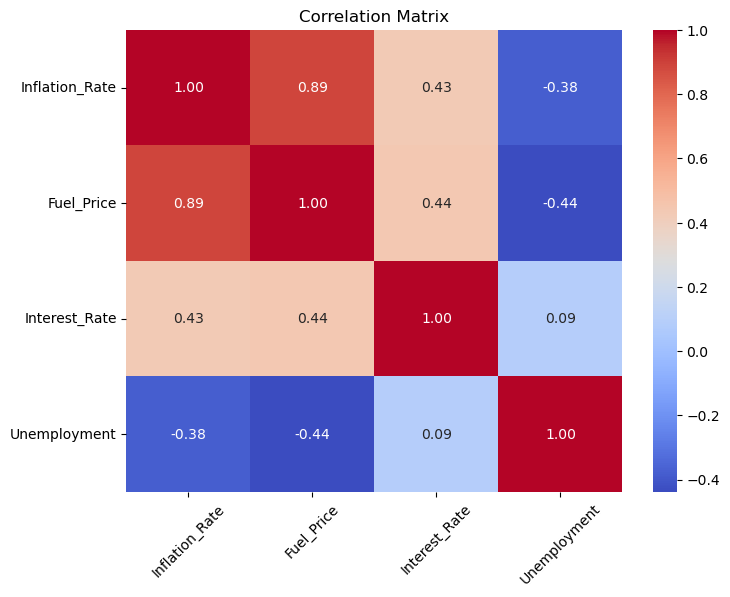

In [411]:

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

# Build ML model

In [412]:
X = final_df[[
    "Fuel_Price",
    "Interest_Rate",
    "Unemployment"
]]

y = final_df["Inflation_Rate"]

In [413]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

In [414]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [415]:
y_pred = model.predict(X_test)

In [416]:

# Training performance
train_pred = model.predict(X_train)
print("Train R2:", r2_score(y_train, train_pred))

# Test performance
print("Test R2:", r2_score(y_test, y_pred))

Train R2: 0.9828683955433052
Test R2: 0.615486110317053


In [417]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.615486110317053
MAE: 0.7980999999999989


The final Random Forest model achieved an R² score of 0.61, indicating that it can explain approximately 61% of the variation in inflation. While not perfect, this level of accuracy is reasonable given the limited dataset and the complexity of economic systems. The model demonstrates that fuel prices, interest rates, and unemployment collectively influence inflation trends.

# Save Model

In [418]:

with open("../model/inflation_model.pkl", "wb") as f:
    pickle.dump(model, f)


# Test loading

In [419]:
model = pickle.load(open("../model/inflation_model.pkl", "rb"))


print(model.predict([[130, 4, 5]]))

[1.675]


c:\Users\Madhurima Acharya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
